In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

https://math.stackexchange.com/questions/5125314/what-type-of-bifurcation-occurs-at-lambda-0-for-the-nonlinear-dynamical-sys?noredirect=1#comment11050269_5125314

In [2]:
def model(t, y, k):
    return np.array([
        y[0] * (y[0] ** 2 - 1.) * (k - y[0] ** 2),
        np.ones(shape=y[1].shape),
    ])

In [3]:
k = 0.25

In [4]:
t = np.linspace(0, 15, 200)

In [5]:
rs = np.linspace(0, 1, 6)
rs

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

In [6]:
solutions = []
for r in rs:
    solution = integrate.solve_ivp(model, [t[0], t[-1]], y0=[r, -7.], t_eval=t, method="LSODA", args=(k,))
    solutions.append(solution)

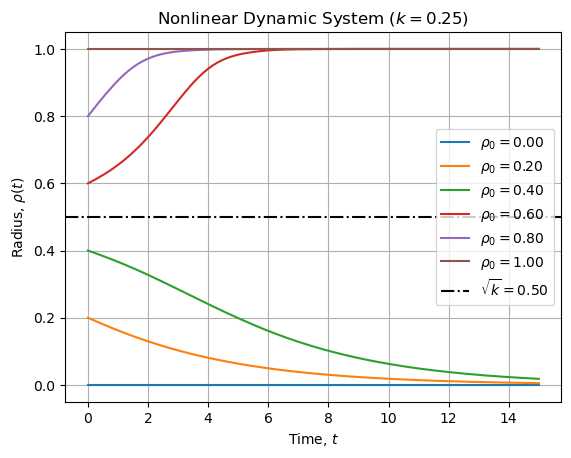

In [7]:
fig, axe = plt.subplots()
for solution, r in zip(solutions, rs):
    axe.plot(t, solution.y[0], label=fr"$\rho_0 = {r:.2f}$")
if k > 0:
    axe.axhline(np.sqrt(k), linestyle="-.", color="black", label=r"$\sqrt{{k}} = {0:.2f}$".format(np.sqrt(k)))
axe.set_title(f"Nonlinear Dynamic System ($k={k}$)")
axe.set_xlabel("Time, $t$")
axe.set_ylabel(r"Radius, $\rho(t)$")
axe.legend()
axe.grid()

In [8]:
rho = np.linspace(-0.25, 1.5, 200)
theta = np.linspace(-3. * np.pi, 3. * np.pi, 200)

In [9]:
R, T = np.meshgrid(rho, theta)

In [10]:
U, V = model(None, [R, T], k)

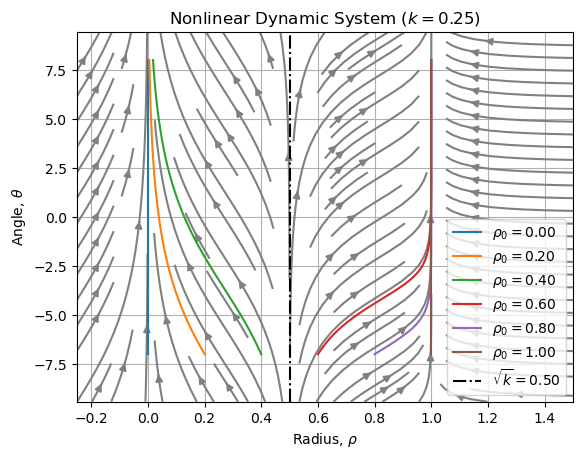

In [11]:
fig, axe = plt.subplots()
axe.streamplot(R, T, U, V, color="gray")
for solution, r in zip(solutions, rs):
    axe.plot(*solution.y, label=fr"$\rho_0 = {r:.2f}$")
if k > 0:
    axe.axvline(np.sqrt(k), linestyle="-.", color="black", label=r"$\sqrt{{k}} = {0:.2f}$".format(np.sqrt(k)))
axe.set_title(f"Nonlinear Dynamic System ($k={k}$)")
axe.set_xlabel(r"Radius, $\rho$")
axe.set_ylabel(r"Angle, $\theta$")
axe.legend()
axe.grid()

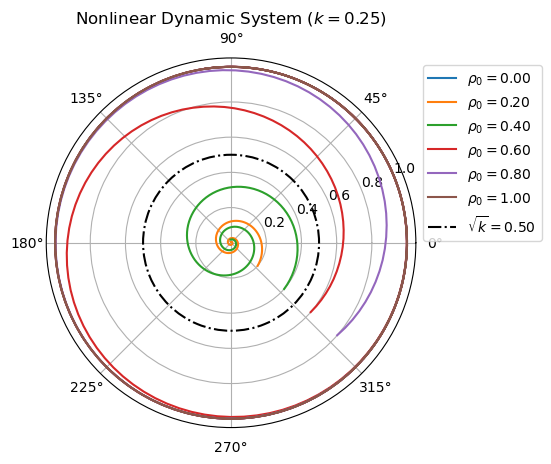

In [12]:
fig, axe = plt.subplots(subplot_kw={'projection': 'polar'})
for solution, r in zip(solutions, rs):
    axe.plot(*np.flip(solution.y), label=rf"$\rho_0 = {r:.2f}$")
if k > 0:
    axe.axhline(np.sqrt(k), linestyle="-.", color="black", label=r"$\sqrt{{k}} = {0:.2f}$".format(np.sqrt(k)))
axe.set_title(f"Nonlinear Dynamic System ($k={k}$)")
axe.legend(bbox_to_anchor=(1, 1))

In [13]:
drhos = []
ks = np.arange(-1, 1.1, 0.25)

In [14]:
for _k in ks:
    drho = model(None, [rho, theta], _k)[0]
    drhos.append(drho)

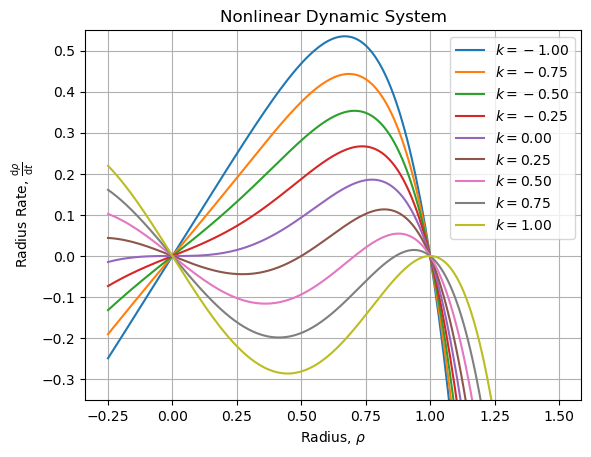

In [15]:
fig, axe = plt.subplots()
for drho, _k in zip(drhos, ks):
    axe.plot(rho, drho, label=rf"$k = {_k:.2f}$")
axe.set_ylim([-0.35, 0.55])
axe.set_title(f"Nonlinear Dynamic System")
axe.set_xlabel(r"Radius, $\rho$")
axe.set_ylabel(r"Radius Rate, $\frac{\mathrm{d}\rho}{\mathrm{d}t}$")
axe.legend()
axe.grid()